In [1]:
# Importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler,ReduceLROnPlateau

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler,ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
# Importing the training dataset

dataset = pd.read_csv('./digit-recognizer/train.csv')
dataset

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Inspecting the dataset

dataset.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [4]:
# Checking for missing values

np.any(dataset.isnull().sum())

np.False_

In [5]:
# Slicing the dataset to separate feature matrix 'X' and the vector of predictions 'y'

X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

X.shape, y.shape, X.dtype, y.dtype

((42000, 784), (42000,), dtype('int64'), dtype('int64'))

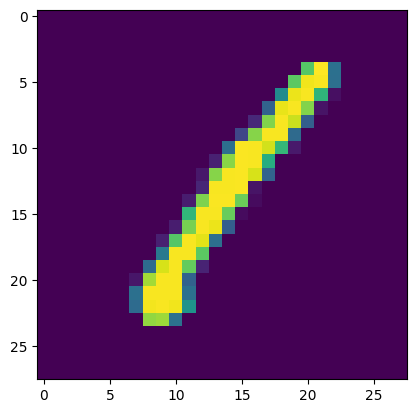

In [6]:
# Visualizing the dataset by reshaping an image into the original format i.e. 28 * 28

first_image = X[0]
first_image = first_image.reshape((28, 28))

plt.imshow(first_image)
plt.show()

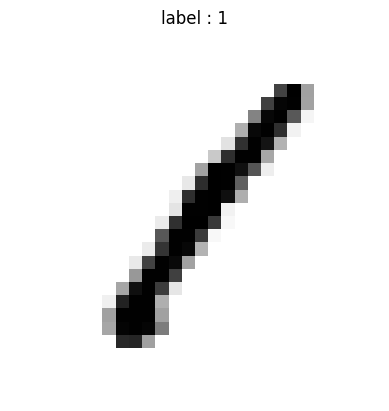

In [7]:
# Grayscaling the image, dropping the axis and printing the label

plt.imshow(first_image, "binary")
plt.title('label : {}'.format(y[0]))
plt.axis('off')
plt.show()

Random Indexes :  [38098 17646 19323 19580 11982  6800 27032  1740 23463 16830 16117  4753
 12446  3321 27534 29609  3376 17248 33261 25732 25360 19913 17206 24947
 27481]

 Shape :  (25, 784)


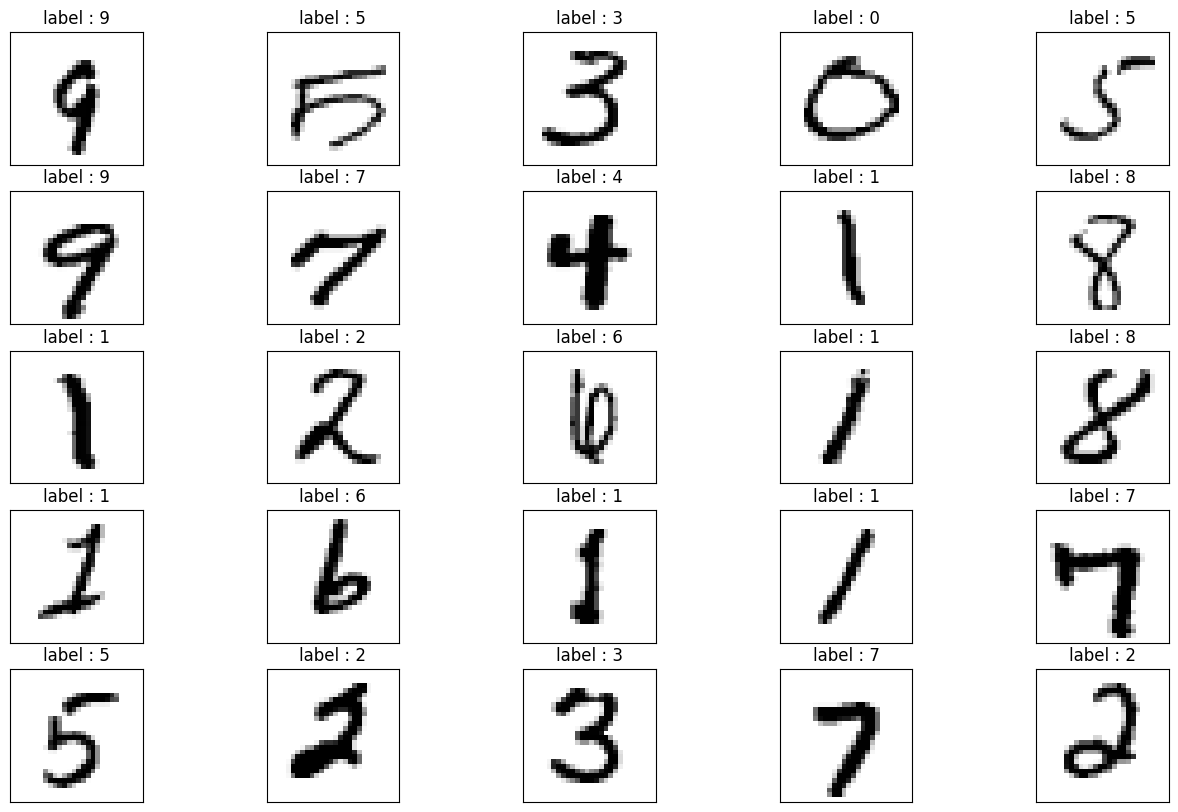

In [8]:
# Plotting multiple randomly chosen images from the dataset for insights

random_indexes = np.random.choice(range(len(X)), 25)
print("Random Indexes : ", random_indexes)

X_random = X[random_indexes]
y_random = y[random_indexes]

print("\n Shape : ", X_random.shape)

plt.figure(figsize = (16, 10))
for i in range(25):
    image = X_random[i]
    image = image.reshape((28, 28))
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(image, "binary")
    plt.title('label : {}'.format(y_random[i]))
plt.show()

In [9]:
# Applying feature scaling for faster convergence

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
# Importing the test set

test_data = pd.read_csv('./digit-recognizer/test.csv')
X_test = test_data.values
X_test.shape

(28000, 784)

In [11]:
# Scaling the test set

X_test_scaled = scaler.fit_transform(X_test)
X_test_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
# Reshaping the data for Image Generator (Rank = 4)

X = X.reshape((42000, 28, 28, 1))

In [13]:
# Applying Data Augmentation

datagen = ImageDataGenerator(rotation_range=10,  zoom_range = 0.1,  width_shift_range=0.1,  height_shift_range=0.1)
# datagen.fit(X)

In [14]:
# An empty list to store the ensemble of 10 CNNs

model_list = []

In [15]:
# Learning rate annealer

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', 
                                patience=3, 
                                verbose=1, 
                                factor=0.2, 
                                min_lr=1e-6)

In [16]:
# Creating 7 objects of the same CNN architecture and saving in model_list

for i in range(7):
    model = keras.models.Sequential([
    keras.layers.Conv2D(32, kernel_size = 3, activation = 'relu', padding = 'same', input_shape = [28, 28, 1]),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, kernel_size = 3, activation = 'relu', padding = 'same'),
    keras.layers.MaxPool2D(),
    keras.layers.Conv2D(32, kernel_size = 3, activation = 'relu', padding = 'same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, kernel_size = 3, activation = 'relu', padding = 'same'),
    keras.layers.MaxPool2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(256, activation = 'relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation = 'softmax')])

    model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
    model_list.append(model)



/opt/miniconda3/envs/tensorflow_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Verifying the hashcodes

model_list

[<Sequential name=sequential, built=True>,
 <Sequential name=sequential_1, built=True>,
 <Sequential name=sequential_2, built=True>,
 <Sequential name=sequential_3, built=True>,
 <Sequential name=sequential_4, built=True>,
 <Sequential name=sequential_5, built=True>,
 <Sequential name=sequential_6, built=True>]

In [18]:
# Reshaping to a tensor of rank 4

# X = X.reshape((42000, 28, 28, 1))
X.shape

(42000, 28, 28, 1)

In [19]:
# Training all the 7 CNNs in the ensemble together

history = [0] * 7

for i in range(7):
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.08)
    history[i] = model_list[i].fit(datagen.flow(X, y, batch_size = 64), 
                                             epochs = 20, validation_data = (X_valid, y_valid), callbacks = [reduce_lr])
    print("CNN : {} Maximum Train Accuracy : {} Maximum Validation Accuracy : {}".format(i+1, max(history[i].history['accuracy']), max(history[i].history['val_accuracy'])))

Epoch 1/20


/opt/miniconda3/envs/tensorflow_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.7586 - loss: 0.7831 - val_accuracy: 0.9774 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.9570 - loss: 0.1454 - val_accuracy: 0.9821 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.9684 - loss: 0.1055 - val_accuracy: 0.9753 - val_loss: 0.0783 - learning_rate: 0.0010
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.9742 - loss: 0.0864 - val_accuracy: 0.9914 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.9757 - loss: 0.0809 - val_accuracy: 0.9798 - val_loss: 0.0686 - learning_rate: 0.0010
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.9788 - loss: 0.0754 - val_accuracy: 0.9929 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.9794 - loss: 0.0697

In [20]:
# Creating a prediction tensor for applying the bagging technique

ensemble_cnn_pred = np.zeros((X_test.shape[0], 10))
ensemble_cnn_pred.shape

(28000, 10)

In [21]:
# Reshaping the test set in a Rank 4 tensor

X_test_scaled = X_test_scaled.reshape((28000, 28, 28, 1))
X_test_scaled.shape

(28000, 28, 28, 1)

In [22]:
# Generating and aggregating predictions

for i in range(7):
  ensemble_cnn_pred = ensemble_cnn_pred + model_list[i].predict(X_test_scaled)

875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [23]:
# Verifying the predictions of the ensemble

np.sum(ensemble_cnn_pred[0])

np.float64(7.000000001648883)

In [24]:
# Aggregating the predictions

ensemble_cnn_pred = np.argmax(ensemble_cnn_pred, axis = 1)
ensemble_cnn_pred[0]

np.int64(2)

In [25]:
# Verifying the shape

ensemble_cnn_pred.shape

(28000,)

In [26]:
# Saving the predictions in a dataframe

pred_df_ensemble_cnn = pd.DataFrame(columns = ['ImageId', 'Label'])
pred_df_ensemble_cnn['ImageId'] = np.arange(1, 28001)
pred_df_ensemble_cnn['Label'] = ensemble_cnn_pred
pred_df_ensemble_cnn

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [27]:
# Writing the predictions in a csv file

pred_df_ensemble_cnn.to_csv('ens_cnn_with_aug_sub.csv', index = False)